In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [4]:
data = load_breast_cancer()

df = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

df["Target"] = data.target

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [6]:
print(df.shape)

print(df.info())

print(df["Target"].value_counts())

(569, 31)
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         56

In [11]:
X = df.drop("Target", axis=1)

y = df["Target"]

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(455, 30)
(114, 30)


In [16]:
rf_model = RandomForestClassifier(
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.9649122807017544


In [18]:
gb_model = GradientBoostingClassifier(
    random_state=42
)

gb_model.fit(
    X_train,
    y_train
)

gb_pred = gb_model.predict(X_test)

gb_accuracy = accuracy_score(
    y_test,
    gb_pred
)

print("Gradient Boosting Accuracy:", gb_accuracy)

Gradient Boosting Accuracy: 0.956140350877193


In [20]:
rf_cv = cross_val_score(
    rf_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

gb_cv = cross_val_score(
    gb_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Random Forest CV Mean:", rf_cv.mean())

print("Gradient Boosting CV Mean:", gb_cv.mean())

Random Forest CV Mean: 0.9560937742586555
Gradient Boosting CV Mean: 0.9631268436578171


In [22]:
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, 10]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(
    X_train,
    y_train
)

print("Best Parameters:")

print(grid.best_params_)

print("Best CV Score:")

print(grid.best_score_)

Best Parameters:
{'max_depth': 10, 'n_estimators': 200}
Best CV Score:
0.9626373626373625


In [24]:
best_model = grid.best_estimator_

best_pred = best_model.predict(X_test)

print(
    "Best Model Accuracy:",
    accuracy_score(y_test, best_pred)
)

print("\nConfusion Matrix\n")

print(confusion_matrix(y_test, best_pred))

print("\nClassification Report\n")

print(classification_report(y_test, best_pred))

Best Model Accuracy: 0.9649122807017544

Confusion Matrix

[[40  3]
 [ 1 70]]

Classification Report

              precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



                 Feature  Importance
23            worst area    0.128510
27  worst concave points    0.128365
22       worst perimeter    0.127080
7    mean concave points    0.119750
20          worst radius    0.069274
6         mean concavity    0.055773
0            mean radius    0.050440
3              mean area    0.042591
26       worst concavity    0.040713
2         mean perimeter    0.038352


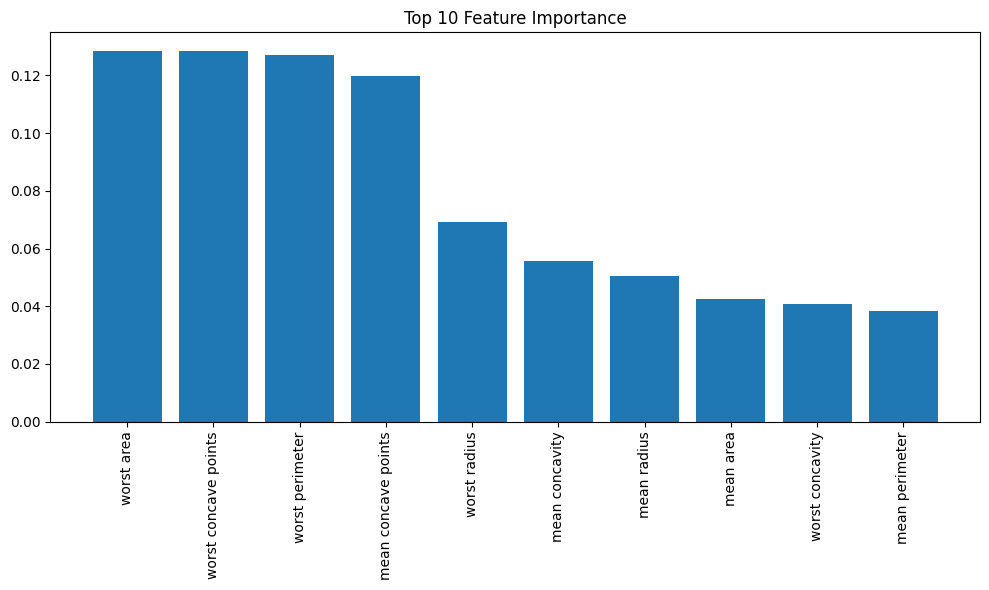

In [25]:
importance = best_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(10))

plt.figure(figsize=(10,6))

plt.bar(
    feature_importance["Feature"][:10],
    feature_importance["Importance"][:10]
)

plt.xticks(rotation=90)

plt.title("Top 10 Feature Importance")

plt.tight_layout()

plt.show()

               Model  Accuracy
0      Random Forest  0.964912
1  Gradient Boosting  0.956140


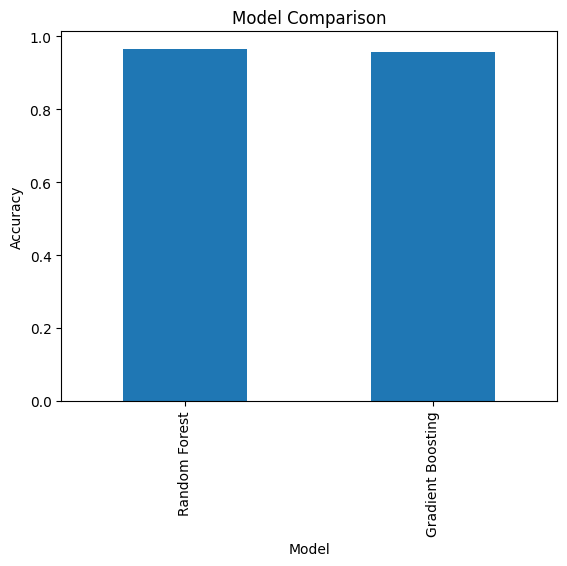

In [26]:
results = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        rf_accuracy,
        gb_accuracy
    ]
})

print(results)

results.plot(
    x="Model",
    y="Accuracy",
    kind="bar",
    legend=False
)

plt.title("Model Comparison")

plt.ylabel("Accuracy")

plt.show()